# Sentence-Level SHAP Analysis (bert_v3)

Loads the `explanations.parquet` files produced by `src/modeling/dl/predict.py --shap` (sentence-level masking, see `src/evaluation/explanation.py`) and reproduces the analysis in `shap_explanations/SHAP_SENTENCE_LEVEL_ANALYSIS.md`.

Covers: attribution magnitude, sign asymmetry, diffuseness of attribution across the document, and whether high-attribution sentences carry recognizable legal content (anchor-keyword enrichment).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Repo root = two levels up from src/evaluation/
REPO_ROOT = Path.cwd().resolve().parents[1] if Path.cwd().name == "evaluation" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "src"))
from modeling.llms.summarizer import ANCHOR_GROUPS

PATHS = {
    "dv": REPO_ROOT / "shap_explanations/domestic_violence/5_gold_set/bert_v3/explanations.parquet",
    "boc": REPO_ROOT / "shap_explanations/breach_of_contract/5_gold_set/bert_v3/explanations.parquet",
}
DISPLAY = {"dv": "Domestic Violence (DV)", "boc": "Breach of Contract (BoC)"}

OUT_DIR = REPO_ROOT / "shap_explanations" / "analysis"
OUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 90)

c:\Users\helto\OneDrive\Documentos\Mestrado Ciência de Dados\Tese de Mestrado\Codigo\tese_mestrado_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load data

One row per (case, sentence). Columns: `case_id`, `case_type`, `model_name`, `sentence_idx` (position in original document order), `sentence_text`, `shap_value_predicted_class`, `shap_values_all_classes`, `predicted_class`, `predicted_label`, `true_label`, `true_label_str`, `output_names`, `predict_proba`, `base_values`.

In [2]:
data = {ct: pd.read_parquet(p) for ct, p in PATHS.items()}
for ct, df in data.items():
    print(f"{ct}: {len(df)} rows, {df.case_id.nunique()} cases")

dv: 2356 rows, 5 cases
boc: 2502 rows, 5 cases


---
# Part 1 — Can the model discriminate at all? (full gold set, n=50)

**Run this before interpreting any SHAP output.** It uses the full 50-case gold-set predictions (not the 5-case SHAP subset) to establish whether the model's output depends on the input at all.

If the output probability carries no information about the true label, then no attribution method can produce meaningful explanations — there is no input-dependent decision process to explain. Everything in Parts 2–3 must be read in that light.

In [3]:
from collections import Counter
from scipy import stats

PRED_SPEC = {
    "dv":  (["proba_MANTIDA", "proba_ALTERADA"], ["MANTIDA", "ALTERADA"]),
    "boc": (["proba_DESFAVORAVEL", "proba_PARCIAL", "proba_FAVORAVEL"],
            ["DESFAVORAVEL", "PARCIAL", "FAVORAVEL"]),
}

preds = {}
for ct, (cols, names) in PRED_SPEC.items():
    df = pd.read_parquet(REPO_ROOT / f"data/models/dl/{ct}/predictions/bert_v3_{ct}_predictions.parquet")
    preds[ct] = (df, cols, names)

    print("=" * 95)
    print(f"{DISPLAY[ct]} — full gold set (n={len(df)})")
    print("-" * 95)
    print("  TRUE labels:", dict(Counter(df.y_true.map(dict(enumerate(names))))))
    print("  PRED labels:", dict(Counter(df.y_pred.map(dict(enumerate(names))))))

    acc = (df.y_true == df.y_pred).mean()
    majority_n = Counter(df.y_true).most_common(1)[0][1]
    print(f"  Accuracy                : {acc*100:.0f}%")
    print(f"  Always-predict-majority : {majority_n/len(df)*100:.0f}%   <-- baseline")

    conf = df[cols].to_numpy().max(axis=1)
    print(f"  Confidence across 50 different documents: "
          f"min={conf.min():.3f} mean={conf.mean():.3f} max={conf.max():.3f} std={conf.std():.4f}")

    # Does P(predicted class) differ between docs whose true label matches vs not?
    pred_class = df.y_pred.iloc[0]           # constant — the model emits one class
    p_pred = df[cols[pred_class]]
    match = p_pred[df.y_true == pred_class]
    other = p_pred[df.y_true != pred_class]
    u, p_mw = stats.mannwhitneyu(match, other, alternative="two-sided")
    auc = u / (len(match) * len(other))
    print(f"  P({names[pred_class]}) | true==pred : {match.mean():.4f} (n={len(match)})")
    print(f"  P({names[pred_class]}) | true!=pred : {other.mean():.4f} (n={len(other)})")
    print(f"     difference={match.mean()-other.mean():+.4f}  Mann-Whitney p={p_mw:.3f}  AUC={auc:.3f}"
          f"   {'<-- indistinguishable' if p_mw > 0.05 else ''}")
    print()

Domestic Violence (DV) — full gold set (n=50)
-----------------------------------------------------------------------------------------------
  TRUE labels: {'MANTIDA': 29, 'ALTERADA': 21}
  PRED labels: {'MANTIDA': 50}
  Accuracy                : 58%
  Always-predict-majority : 58%   <-- baseline
  Confidence across 50 different documents: min=0.724 mean=0.842 max=0.878 std=0.0312
  P(MANTIDA) | true==pred : 0.8450 (n=29)
  P(MANTIDA) | true!=pred : 0.8372 (n=21)
     difference=+0.0078  Mann-Whitney p=0.694  AUC=0.534   <-- indistinguishable

Breach of Contract (BoC) — full gold set (n=50)
-----------------------------------------------------------------------------------------------
  TRUE labels: {'DESFAVORAVEL': 35, 'PARCIAL': 9, 'FAVORAVEL': 6}
  PRED labels: {'DESFAVORAVEL': 50}
  Accuracy                : 70%
  Always-predict-majority : 70%   <-- baseline
  Confidence across 50 different documents: min=0.643 mean=0.803 max=0.889 std=0.0490
  P(DESFAVORAVEL) | true==pred : 0.807

---
# Part 2 — Mechanism: why the attributions look the way they do

## 2.1 Base values explain the DV (all-red) vs BoC (red+blue) difference

SHAP's efficiency axiom: `base_value + Σ(SHAP) = predicted probability`, where `base_value` is the model's output on a **fully masked (empty) input** — i.e. its prior before seeing any text.

The size of the gap between base and prediction determines how much *net positive* attribution mass must exist, which in turn constrains how many sentences can be negative.

In [4]:
rows = []
for ct, df in data.items():
    for cid, d in df.groupby("case_id"):
        k = d.predicted_class.iloc[0]
        rows.append({
            "case_type": ct.upper(),
            "case_id": cid,
            "n_sentences": len(d),
            "base_value": d.base_values.iloc[0][k],
            "sum_shap": d.shap_value_predicted_class.sum(),
            "base+sum": d.base_values.iloc[0][k] + d.shap_value_predicted_class.sum(),
            "actual_proba": d.predict_proba.iloc[0][k],
            "pct_positive": (d.shap_value_predicted_class > 0).mean() * 100,
        })
eff = pd.DataFrame(rows)
# Efficiency axiom check: base + sum(SHAP) should reproduce the prediction
eff["axiom_err"] = (eff["base+sum"] - eff.actual_proba).abs()
print(f"Max efficiency-axiom error across all cases: {eff.axiom_err.max():.2e}  (should be ~0)\n")
display(eff.drop(columns="axiom_err").round(4))

print("\nBase value is constant within each case type (it is the model's output on empty input):")
print(eff.groupby("case_type").base_value.agg(["min", "max"]).round(4))
print("\nDV needs a much larger net positive push to reach its prediction, leaving")
print("almost no room for negative sentences -> ~99% red. BoC starts from a higher")
print("prior, needs about half the push, so large +/- values can coexist -> red AND blue.")

Max efficiency-axiom error across all cases: 0.00e+00  (should be ~0)



,case_type,case_id,n_sentences,base_value,sum_shap,base+sum,actual_proba,pct_positive
0,DV,123_22.5PACTX.E1,919,0.4887,0.3484,0.8371,0.8371,100.0000
1,DV,340_21.5TXLSB-E.L1-9,460,0.4887,0.3893,0.8781,0.8781,100.0000
2,DV,5052_21.7JAPRT-A.P1,267,0.4887,0.3807,0.8694,0.8694,99.6255
3,DV,65_24.0GEBRG.G1,367,0.4887,0.3476,0.8363,0.8363,97.0027
4,DV,87_25.3PGSXL-A.L1-5,343,0.4887,0.2867,0.7754,0.7754,94.1691
5,BOC,13951_22.2T8LSB-A.L1.S1,286,0.5855,0.2347,0.8202,0.8202,76.5734
6,BOC,1627_20.0T8PVZ.P1,341,0.5855,0.1493,0.7348,0.7348,58.9443
7,BOC,17126_26.0T8PRT.P1,760,0.5855,0.1896,0.7751,0.7751,73.1579
8,BOC,18203_23.8T8SNT.L1-6,410,0.5855,0.2288,0.8143,0.8143,78.2927
9,BOC,1980_19.8T8CTB.C1,705,0.5855,0.1785,0.7640,0.7640,79.1489



Base value is constant within each case type (it is the model's output on empty input):
              min     max
case_type                
BOC        0.5855  0.5855
DV         0.4887  0.4887

DV needs a much larger net positive push to reach its prediction, leaving
almost no room for negative sentences -> ~99% red. BoC starts from a higher
prior, needs about half the push, so large +/- values can coexist -> red AND blue.


## 2.2 Per-sentence magnitude is mostly document length, not signal

Because prediction and base value are both near-constant, the **total** attribution mass per document is near-constant too — and does not scale with document length. So per-sentence magnitude ≈ `constant / n_sentences`.

Consequence: do **not** compare SHAP magnitudes between documents of different lengths, and do not read anything into "the values are small."

Also checked here: for the binary DV task the two class columns are exact negatives of each other (probabilities sum to 1), so "pushes toward MANTIDA" and "pushes away from ALTERADA" are one signal, not two.

In [5]:
print("Total attribution mass vs document length\n")
for ct in ["dv", "boc"]:
    sub = eff[eff.case_type == ct.upper()].copy()
    sub["mean_shap"] = sub.sum_shap / sub.n_sentences
    corr = sub.n_sentences.corr(sub.sum_shap)
    print(f"{DISPLAY[ct]}:  corr(n_sentences, total mass) = {corr:+.3f}")
    display(sub[["case_id", "n_sentences", "sum_shap", "mean_shap"]]
            .sort_values("n_sentences").round(6))
    lo, hi = sub.n_sentences.min(), sub.n_sentences.max()
    m_lo = sub.loc[sub.n_sentences.idxmin(), "mean_shap"]
    m_hi = sub.loc[sub.n_sentences.idxmax(), "mean_shap"]
    print(f"   shortest doc ({lo} sents) mean SHAP = {m_lo:.6f}")
    print(f"   longest  doc ({hi} sents) mean SHAP = {m_hi:.6f}")
    print(f"   length ratio {hi/lo:.1f}x  vs  magnitude ratio {m_lo/m_hi:.1f}x  <- track each other\n")

# Binary mirroring check (DV only)
arr = np.vstack(data["dv"].shap_values_all_classes.values)
print(f"DV binary columns exact negatives? max|col0+col1| = {np.abs(arr[:, 0] + arr[:, 1]).max():.2e}")
arr_b = np.vstack(data["boc"].shap_values_all_classes.values)
print(f"BoC 3 columns sum to zero?         max|sum|       = {np.abs(arr_b.sum(axis=1)).max():.2e}")

Total attribution mass vs document length

Domestic Violence (DV):  corr(n_sentences, total mass) = +0.022


,case_id,n_sentences,sum_shap,mean_shap
2,5052_21.7JAPRT-A.P1,267,0.380724,0.001426
4,87_25.3PGSXL-A.L1-5,343,0.286721,0.000836
3,65_24.0GEBRG.G1,367,0.347604,0.000947
1,340_21.5TXLSB-E.L1-9,460,0.389340,0.000846
0,123_22.5PACTX.E1,919,0.348409,0.000379


   shortest doc (267 sents) mean SHAP = 0.001426
   longest  doc (919 sents) mean SHAP = 0.000379
   length ratio 3.4x  vs  magnitude ratio 3.8x  <- track each other

Breach of Contract (BoC):  corr(n_sentences, total mass) = -0.292


,case_id,n_sentences,sum_shap,mean_shap
5,13951_22.2T8LSB-A.L1.S1,286,0.234723,0.000821
6,1627_20.0T8PVZ.P1,341,0.149280,0.000438
8,18203_23.8T8SNT.L1-6,410,0.228799,0.000558
9,1980_19.8T8CTB.C1,705,0.178516,0.000253
7,17126_26.0T8PRT.P1,760,0.189563,0.000249


   shortest doc (286 sents) mean SHAP = 0.000821
   longest  doc (760 sents) mean SHAP = 0.000249
   length ratio 2.7x  vs  magnitude ratio 3.3x  <- track each other

DV binary columns exact negatives? max|col0+col1| = 1.62e-09
BoC 3 columns sum to zero?         max|sum|       = 4.06e-09


## 2.3 The 5-case SHAP subset — per-case predictions

Context for the subset the SHAP explanations were computed on. Same single-class pattern as the full gold set in Part 1: all 5 cases per type receive the same predicted label.

In [6]:
for ct, df in data.items():
    print("=" * 90)
    print(DISPLAY[ct])
    g = df.groupby("case_id").agg(n_sentences=("sentence_idx", "size"),
                                   predicted=("predicted_label", "first"),
                                   true=("true_label_str", "first"))
    g["confidence"] = df.groupby("case_id").apply(
        lambda d: d.predict_proba.iloc[0][d.predicted_class.iloc[0]], include_groups=False
    ).round(3)
    g["correct"] = g.predicted == g.true
    display(g)

Domestic Violence (DV)


,n_sentences,predicted,true,confidence,correct
case_id,,,,,
123_22.5PACTX.E1,919,decisao_mantida,decisao_mantida,0.837,True
340_21.5TXLSB-E.L1-9,460,decisao_mantida,decisao_mantida,0.878,True
5052_21.7JAPRT-A.P1,267,decisao_mantida,decisao_alterada,0.869,False
65_24.0GEBRG.G1,367,decisao_mantida,decisao_mantida,0.836,True
87_25.3PGSXL-A.L1-5,343,decisao_mantida,decisao_mantida,0.775,True


Breach of Contract (BoC)


,n_sentences,predicted,true,confidence,correct
case_id,,,,,
13951_22.2T8LSB-A.L1.S1,286,decisao_desfavoravel,decisao_desfavoravel,0.820,True
1627_20.0T8PVZ.P1,341,decisao_desfavoravel,decisao_desfavoravel,0.735,True
17126_26.0T8PRT.P1,760,decisao_desfavoravel,decisao_desfavoravel,0.775,True
18203_23.8T8SNT.L1-6,410,decisao_desfavoravel,decisao_favoravel,0.814,False
1980_19.8T8CTB.C1,705,decisao_desfavoravel,decisao_parcial,0.764,False


## 2.4 Magnitude and sign summary

Aggregate view of what 2.1–2.2 explain: the sign skew (`pct_positive`) follows from the base-value gap, and the magnitudes follow from document length.

In [7]:
rows = []
for ct, df in data.items():
    s = df.shap_value_predicted_class
    rows.append({
        "case_type": DISPLAY[ct],
        "n_sentences": len(s),
        "mean_shap": s.mean(),
        "median_shap": s.median(),
        "std_shap": s.std(),
        "mean_abs_shap": s.abs().mean(),
        "max_abs_shap": s.abs().max(),
        "pct_positive": (s > 0).mean() * 100,
    })
summary_df = pd.DataFrame(rows).set_index("case_type")
summary_df.round(6)

,n_sentences,mean_shap,median_shap,std_shap,mean_abs_shap,max_abs_shap,pct_positive
case_type,,,,,,,
Domestic Violence (DV),2356,0.000744,0.000579,0.000768,0.000751,0.016139,98.641766
Breach of Contract (BoC),2502,0.000392,0.000352,0.001855,0.000861,0.028634,74.140687


## 2.5 Diffuse or decisive? (shared y-axis)

SHAP value vs. sentence position, in original document order.

**All panels use one shared y-axis across both case types**, so magnitudes are directly comparable. This matters: with per-panel autoscaling, DV's very small values get visually stretched to look like BoC's much larger ones. On a common scale DV is nearly flat while BoC shows real structure.

A few tall isolated spikes against a near-zero baseline would suggest the model keys off a small number of decisive sentences. A continuous noisy band suggests diffuse, non-decisive attribution.

global max |SHAP| = 0.02863  ->  shared ylim = +/-0.03


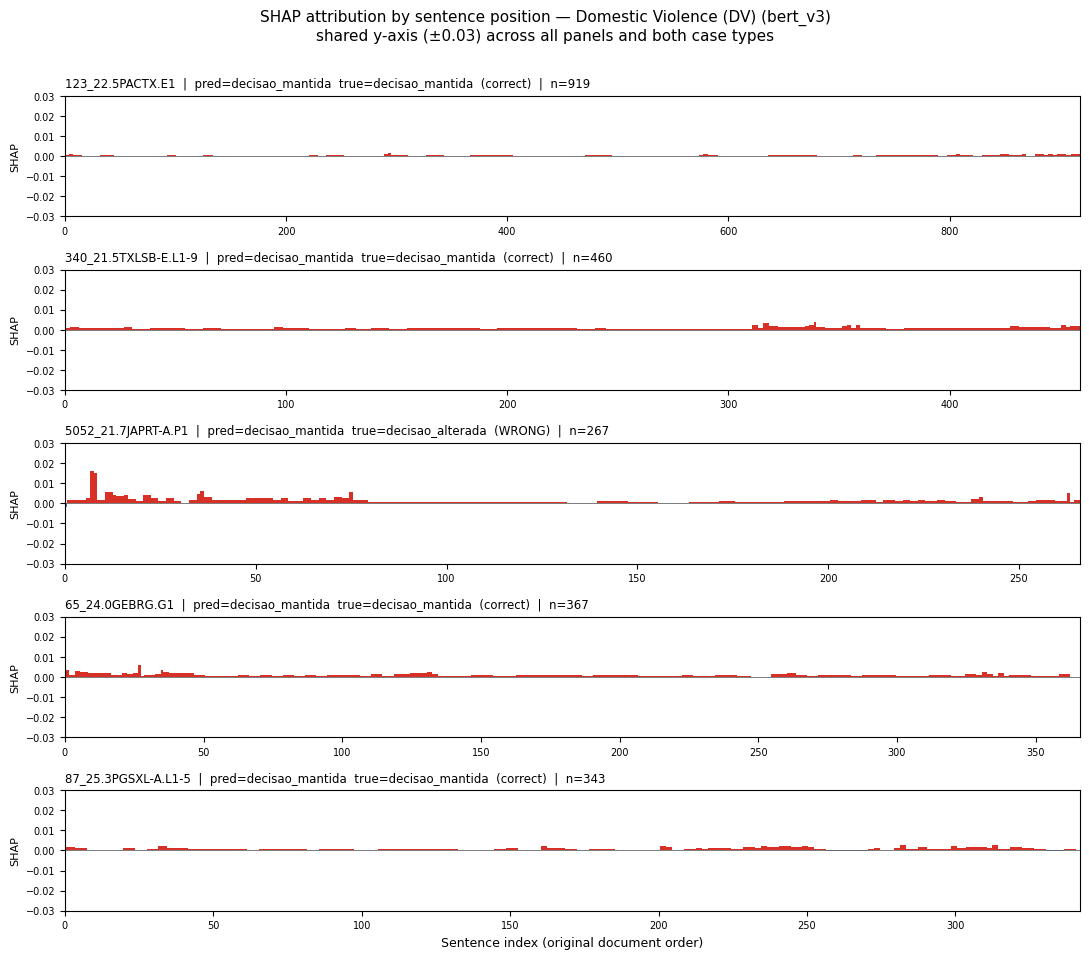

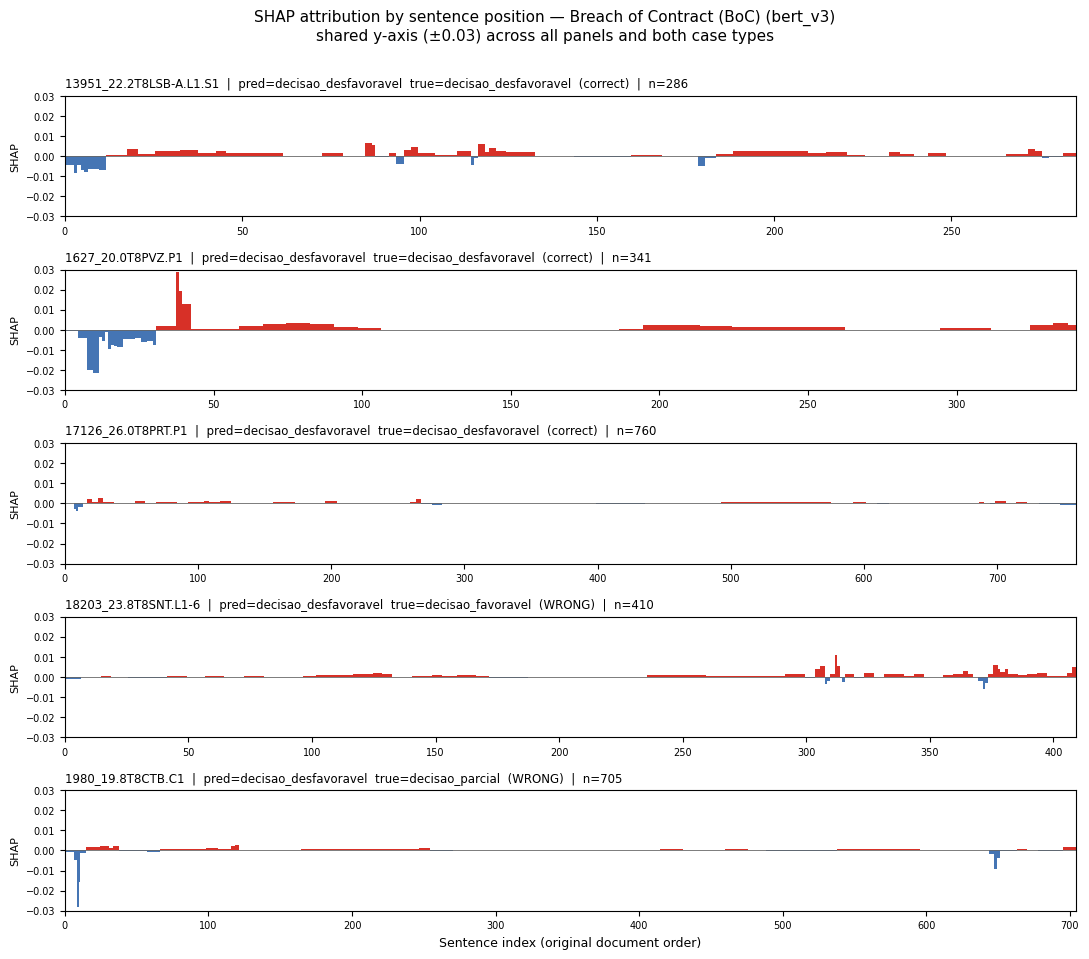

In [8]:
# One shared symmetric y-limit across BOTH case types, so every panel is comparable.
GLOBAL_MAX = max(df.shap_value_predicted_class.abs().max() for df in data.values())
YLIM = float(np.ceil(GLOBAL_MAX * 100) / 100)   # round up to nearest 0.01
print(f"global max |SHAP| = {GLOBAL_MAX:.5f}  ->  shared ylim = +/-{YLIM}")


def plot_shap_by_position(case_type: str, df: pd.DataFrame, ylim: float, save: bool = True):
    """One subplot per case, all on the same y-scale."""
    cases = sorted(df.case_id.unique())
    fig, axes = plt.subplots(len(cases), 1, figsize=(11, 1.9 * len(cases)), sharey=True)
    axes = np.atleast_1d(axes)

    for ax, cid in zip(axes, cases):
        d = df[df.case_id == cid].sort_values("sentence_idx")
        vals, idx = d.shap_value_predicted_class.to_numpy(), d.sentence_idx.to_numpy()
        ax.bar(idx, vals, width=1.0,
               color=np.where(vals >= 0, "#d73027", "#4575b4"), linewidth=0)
        ax.axhline(0, color="#666666", linewidth=0.6)
        pred, true = d.predicted_label.iloc[0], d.true_label_str.iloc[0]
        mark = "correct" if pred == true else "WRONG"
        ax.set_title(f"{cid}  |  pred={pred}  true={true}  ({mark})  |  n={len(d)}",
                     fontsize=8.5, loc="left")
        ax.set_ylabel("SHAP", fontsize=8)
        ax.set_ylim(-ylim, ylim)
        ax.tick_params(labelsize=7)
        ax.set_xlim(0, idx.max())

    axes[-1].set_xlabel("Sentence index (original document order)", fontsize=9)
    fig.suptitle(f"SHAP attribution by sentence position — {DISPLAY[case_type]} (bert_v3)\n"
                 f"shared y-axis (±{ylim}) across all panels and both case types",
                 fontsize=11, y=1.005)
    fig.tight_layout()
    if save:
        fig.savefig(OUT_DIR / f"{case_type}_shap_by_position_shared_scale.png",
                    dpi=150, bbox_inches="tight")
    return fig


for ct in ["dv", "boc"]:
    plot_shap_by_position(ct, data[ct], YLIM)
    plt.show()

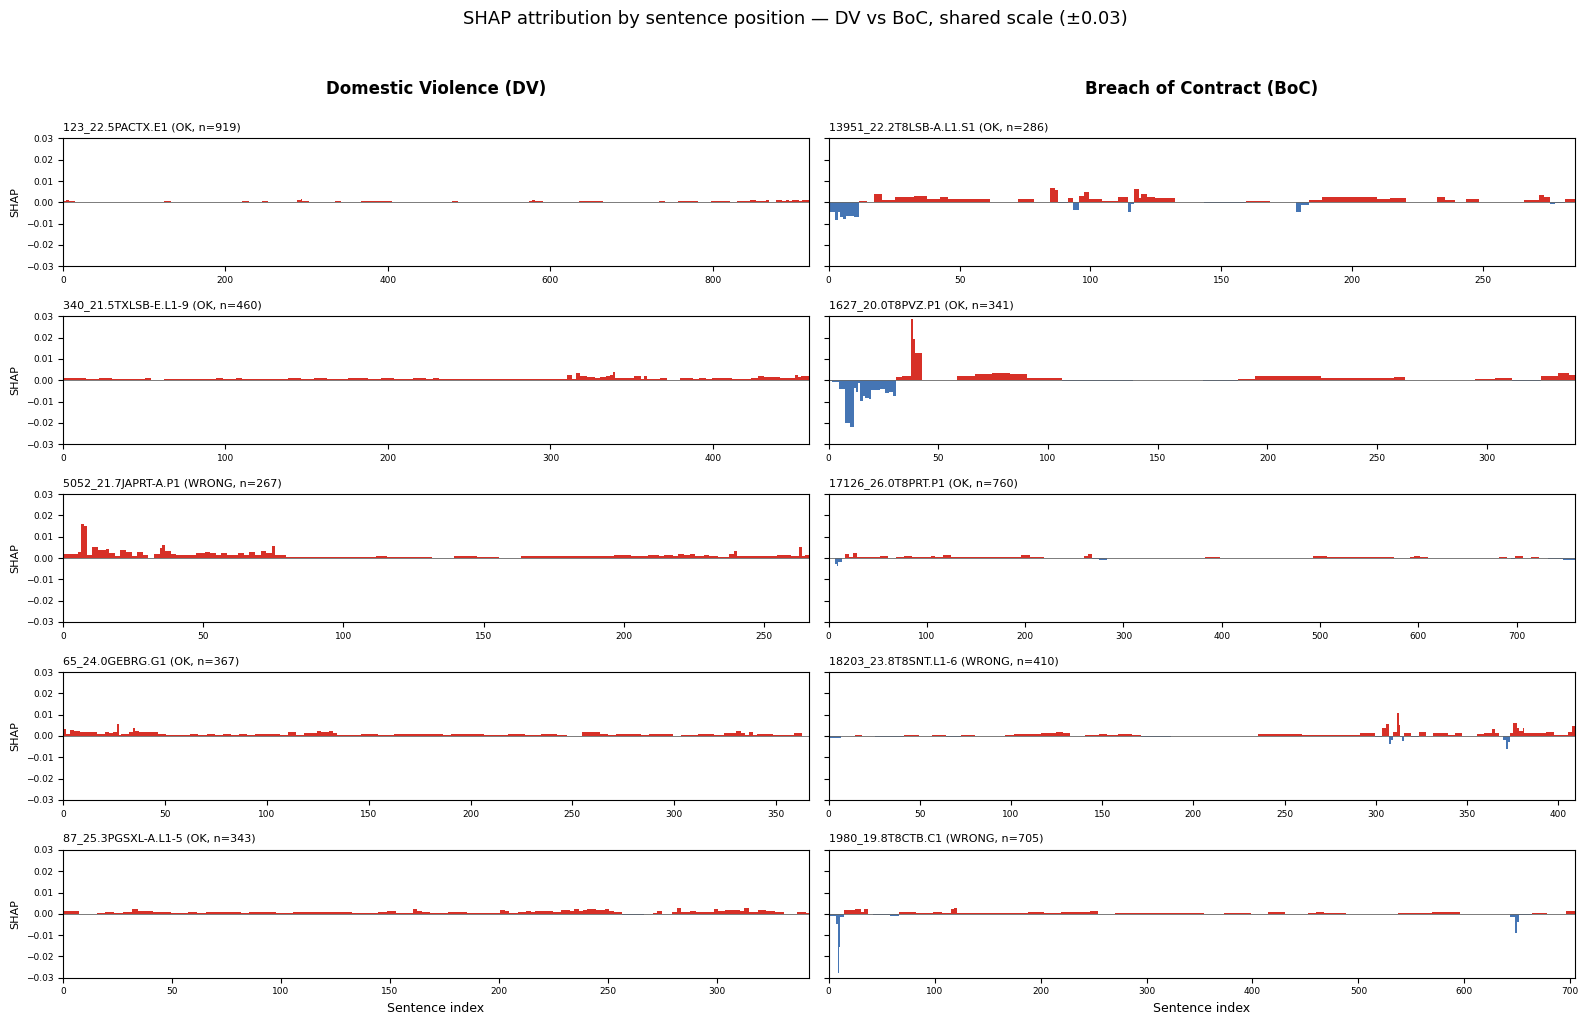

In [9]:
# Combined DV vs BoC on one shared scale — this is the figure recommended for the thesis appendix.
fig, axes = plt.subplots(5, 2, figsize=(16, 10), sharey=True)
for col, ct in enumerate(["dv", "boc"]):
    df = data[ct]
    for row, cid in enumerate(sorted(df.case_id.unique())):
        ax = axes[row, col]
        d = df[df.case_id == cid].sort_values("sentence_idx")
        vals, idx = d.shap_value_predicted_class.to_numpy(), d.sentence_idx.to_numpy()
        ax.bar(idx, vals, width=1.0,
               color=np.where(vals >= 0, "#d73027", "#4575b4"), linewidth=0)
        ax.axhline(0, color="#666666", linewidth=0.6)
        mark = "OK" if d.predicted_label.iloc[0] == d.true_label_str.iloc[0] else "WRONG"
        ax.set_title(f"{cid} ({mark}, n={len(d)})", fontsize=8, loc="left")
        ax.set_ylim(-YLIM, YLIM)
        ax.tick_params(labelsize=6.5)
        ax.set_xlim(0, idx.max())
        if col == 0:
            ax.set_ylabel("SHAP", fontsize=8)
    axes[0, col].text(0.5, 1.35, DISPLAY[ct], transform=axes[0, col].transAxes,
                      ha="center", fontsize=12, fontweight="bold")

axes[-1, 0].set_xlabel("Sentence index", fontsize=9)
axes[-1, 1].set_xlabel("Sentence index", fontsize=9)
fig.suptitle(f"SHAP attribution by sentence position — DV vs BoC, shared scale (±{YLIM})",
             fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(OUT_DIR / "combined_shap_by_position_shared_scale.png", dpi=150, bbox_inches="tight")
plt.show()

---
# Part 3 — Treat with caution: legal-anchor enrichment

> **Do not report this as a finding.** Kept as a documented null result only.
>
> Part 1 established that the model's output is statistically independent of the true label (AUC 0.53 / 0.59, p = 0.69 / 0.34). Any apparent relationship between attribution rank and legal content therefore **cannot** be a consequence of the model recognising legal meaning — it has no demonstrable ability to recognise the outcome at all.
>
> With 5 cases per type and anchor rates in the single digits, one or two sentences entering or leaving a top-20 list swings the percentage by ~5 points. DV and BoC also disagree in direction, which is what noise looks like.

Method: a sentence "has an anchor" if it contains any keyword pattern from `summarizer.ANCHOR_GROUPS` (facts, norms, proof evaluation, reasoning, jurisprudence, conflict) — the same heuristic the smart summarization pipeline uses. It is a crude proxy for "carries recognizable legal-reasoning content," and inherits that pipeline's known limitations.

Comparison: % of all sentences with an anchor (baseline) vs. % of the top-20 highest-|SHAP| sentences, per case, each case weighted equally.

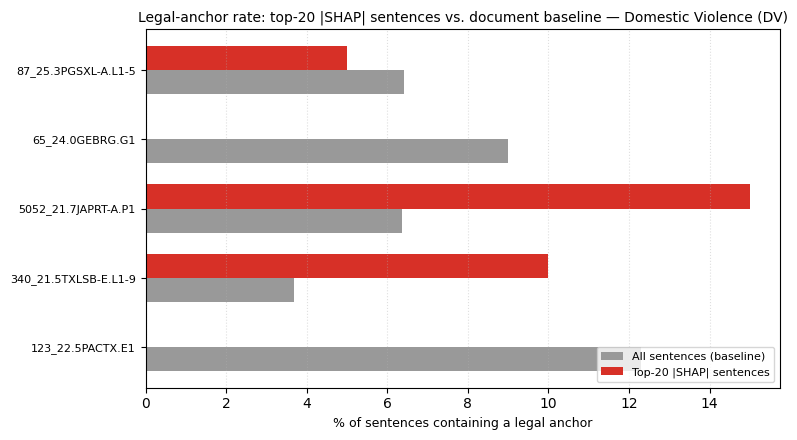

Domestic Violence (DV): pooled baseline=8.6%  pooled top-20=6.0%


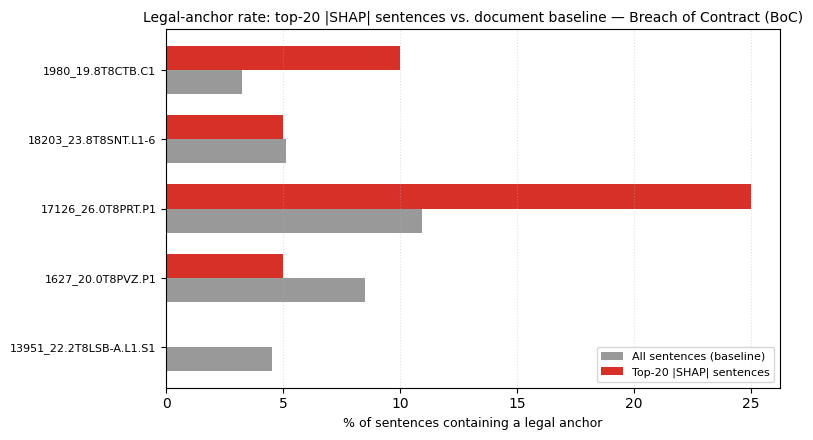

Breach of Contract (BoC): pooled baseline=6.8%  pooled top-20=9.0%


In [10]:
def anchor_categories(sentence: str) -> set[str]:
    s = str(sentence).lower()
    return {cat for cat, patterns in ANCHOR_GROUPS.items() if any(p in s for p in patterns)}


def plot_anchor_enrichment(case_type: str, df: pd.DataFrame, top_k: int = 20, save: bool = True) -> plt.Figure:
    df = df.copy()
    df["has_anchor"] = df.sentence_text.map(lambda s: len(anchor_categories(s)) > 0)

    rows = []
    for cid, d in df.groupby("case_id"):
        baseline = d.has_anchor.mean() * 100
        top = d.reindex(d.shap_value_predicted_class.abs().sort_values(ascending=False).index).head(top_k)
        rows.append((cid, baseline, top.has_anchor.mean() * 100))

    fig, ax = plt.subplots(figsize=(8, 0.6 * len(rows) + 1.5))
    y = np.arange(len(rows))
    labels, baselines, topk_rates = zip(*rows)

    height = 0.35
    ax.barh(y - height / 2, baselines, height=height, color="#999999", label="All sentences (baseline)")
    ax.barh(y + height / 2, topk_rates, height=height, color="#d73027", label=f"Top-{top_k} |SHAP| sentences")
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel("% of sentences containing a legal anchor", fontsize=9)
    ax.set_title(f"Legal-anchor rate: top-{top_k} |SHAP| sentences vs. document baseline — {DISPLAY[case_type]}", fontsize=10)
    ax.legend(fontsize=8, loc="lower right")
    ax.grid(axis="x", linestyle=":", alpha=0.4)
    fig.tight_layout()
    if save:
        fig.savefig(OUT_DIR / f"{case_type}_anchor_enrichment.png", dpi=150, bbox_inches="tight")
    return fig, pd.DataFrame(rows, columns=["case_id", "baseline_pct", "top20_pct"])


for ct in ["dv", "boc"]:
    fig, enrichment_df = plot_anchor_enrichment(ct, data[ct])
    plt.show()
    pooled_baseline = data[ct].sentence_text.map(lambda s: len(anchor_categories(s)) > 0).mean() * 100
    top20_pooled = pd.concat([
        d.reindex(d.shap_value_predicted_class.abs().sort_values(ascending=False).index).head(20)
        for _, d in data[ct].groupby("case_id")
    ])
    top20_pooled_rate = top20_pooled.sentence_text.map(lambda s: len(anchor_categories(s)) > 0).mean() * 100
    print(f"{DISPLAY[ct]}: pooled baseline={pooled_baseline:.1f}%  pooled top-20={top20_pooled_rate:.1f}%")

## Example tables — mixed legal / boilerplate sentences at similar SHAP magnitude

Qualitative companion to Finding 4: for a chosen case, show the top-N highest-|SHAP| sentences with their anchor flag side by side, so it's visible that legally meaningful and purely procedural/boilerplate sentences sit at similar attribution magnitude. See `shap_explanations/analysis/example_tables.md` for the curated write-up (one anchor-rich and one anchor-poor case per case type).

In [11]:
def example_table(case_type: str, case_id: str, top_n: int = 12) -> pd.DataFrame:
    """Top-N highest-|SHAP| sentences for one case, annotated with anchor category."""
    d = data[case_type]
    d = d[d.case_id == case_id].copy()
    d["cats"] = d.sentence_text.map(anchor_categories)
    d["has_anchor"] = d.cats.map(lambda c: len(c) > 0)
    top = d.reindex(d.shap_value_predicted_class.abs().sort_values(ascending=False).index).head(top_n)
    out = top[["shap_value_predicted_class", "has_anchor", "cats", "sentence_text"]].copy()
    out["cats"] = out.cats.map(lambda c: ", ".join(sorted(c)) if c else "-")
    out["sentence_text"] = out.sentence_text.map(lambda s: " ".join(str(s).split()))
    return out.reset_index(drop=True)


# Pick one anchor-rich and one anchor-poor case per case type (see enrichment plot above for rates)
for ct, cid in [("dv", "5052_21.7JAPRT-A.P1"), ("dv", "65_24.0GEBRG.G1"),
                ("boc", "17126_26.0T8PRT.P1"), ("boc", "13951_22.2T8LSB-A.L1.S1")]:
    print(f"\n=== {ct.upper()} — {cid} ===")
    display(example_table(ct, cid))


=== DV — 5052_21.7JAPRT-A.P1 ===


,shap_value_predicted_class,has_anchor,cats,sentence_text
0,0.016139,False,-,"Decisão condenatória Nos presentes autos, por despacho datado de 25/10/2024 foi decidi..."
1,0.014971,False,-,"art.º 171º nº1 do Código Penal, suspensa na sua execução pelo mesmo período de tempo e..."
2,0.006320,False,-,"14) Assim, não deveria ter sido concedida a não transcrição da decisão condenatória pr..."
3,0.005849,False,-,"O arguido foi condenado, no âmbito do processo comum singular n.º 5052/21.7JAPRT, do J..."
4,0.005443,False,-,1) Nos presentes autos foi o arguido condenado pela prática de dois crimes de abuso se...
5,0.005443,False,-,Recurso interposto pelo Ministério Público O Ministério Público não se conformou com e...
6,0.005253,True,jurisprudence,A verificação dos pressupostos previstos no art.º 13º da Lei nº 37/2015 no âmbito do e...
7,0.004518,False,-,"13) É certo que o risco do cometimento de novos crimes, até pelo efeito da condenação ..."
8,0.004128,True,norms,2) O Tribunal deferiu o requerido aplicando mutatis mutandis o juízo realizado no âmbi...
9,0.004034,False,-,171º nº1 e 177º nº1 c) do C.



=== DV — 65_24.0GEBRG.G1 ===


,shap_value_predicted_class,has_anchor,cats,sentence_text
0,0.005704,False,-,"489.º nº 2 do CP, que refere que “A indemnização será, todavia calculada de forma a nã..."
1,0.003573,False,-,"ENCONTRANDO-SE ASSIM PREENCHIDOS DE FORMA SUFICIENTE, ADEQUADA E PROPORCIONAL OS REQUI..."
2,0.003291,False,-,Acordam em conferência na Secção Penal do Tribunal da Relação de Guimarães:
3,0.003291,False,-,"I – Relatório No processo comum singular com o NUIPC 65/24.0GEBRG, que corre termos no..."
4,0.002990,False,-,a) do Código Penal;
5,0.002990,False,-,a) e n.º 2 al.
6,0.002550,False,-,"O Ministério Público respondeu ao recurso interposto, que rematou com as seguintes con..."
7,0.002550,False,-,"EXAS., VENERANDOS JUÍZES DESEMBARGADORES, A COSTUMADA E SÃ JUSTIÇA!» * 3."
8,0.002424,False,-,"d) Condenar a arguida no pagamento das custas penais, fixam-se em 3 (três) UC’s a taxa..."
9,0.002424,False,-,c) Determinar a aplicação a este da medida de internamento em estabelecimento de psiqu...



=== BOC — 17126_26.0T8PRT.P1 ===


,shap_value_predicted_class,has_anchor,cats,sentence_text
0,-0.003743,True,facts,a quantia que se vier a liquidar pelos trabalhos supra discriminados em 12 dos Factos ...
1,-0.002618,False,-,a pagar à A.
2,-0.002618,False,-,"Julgo a ação parcialmente procedente, e, em consequência, condeno a R."
3,0.002496,False,-,dos demais pedidos.;
4,0.002496,True,facts,a quantia que se vier a liquidar pela reparação dos defeitos supra discriminados em 24...
5,0.002496,True,facts,"b) Porém, tal decisão não está correcta, tendo o tribunal incorrido em erro de julgame..."
6,0.002496,True,facts,"c) Considerando os factos insertos na fundamentação da sentença, entende a apelante qu..."
7,0.002003,False,-,Do n.º 1 da Cláusula 9ª do contrato de empreitada dos autos resulta que o empreiteiro ...
8,0.002003,False,-,20.
9,0.002003,False,-,21.



=== BOC — 13951_22.2T8LSB-A.L1.S1 ===


,shap_value_predicted_class,has_anchor,cats,sentence_text
0,-0.008478,False,-,"(i)À 1ª Autora , da quantia global de €3.656.138,63 por incumprimento contratual, acre..."
1,-0.007856,False,-,"A condenação da 2ª Ré, solidariamente com a 1ª Ré, a pagar:"
2,-0.006974,False,-,"À 2ª Autora, do montante de €595.185,36, por consubstanciar um enriquecimento sem caus..."
3,-0.006974,False,-,"À 1ª Autora, do montante de €3.656.138,63, por consubstanciar um enriquecimento sem ca..."
4,-0.006799,False,-,"Autora , da quantia global de €595.185,36, por incumprimento contratual, acrescida de ..."
5,0.006602,False,-,T .
6,0.006602,False,-,"Sendo certo que, não tendo a 2ª Ré subscrito a convenção arbitral, não sendo parte con..."
7,-0.006277,False,-,"(iii)À 1ª Autora , o montante global de €3.656.138,63, por incumprimento contratual, a..."
8,-0.006277,False,-,"Ou a assim não se entender , A condenação da 1.ª Ré na restituição:"
9,-0.006277,False,-,"(iv) À 2ª Autora , o montante global de €595.185,36, por incumprimento contratual, acr..."
